# Q2. Unsupervised Learning — Customer Segmentation with K-Means + PCA

## Task 1: Data Preparation

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('../data/q2_customers.csv')
print("Shape:", df.shape)
print()
print("Data Types:")
print(df.dtypes)
print()
print("Missing Values:", df.isnull().sum().sum())
print()
print("First 5 rows:")
df.head()

Shape: (500, 6)

Data Types:
age                         int64
annual_spend                int64
visits_per_month            int64
basket_size                 int64
days_since_last_visit       int64
num_categories_purchased    int64
dtype: object

Missing Values: 0

First 5 rows:


,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,30,43075,9,2080,45,6
1,19,14496,11,454,8,3
2,43,57632,6,2144,16,4
3,30,15629,10,801,0,2
4,19,14901,16,396,17,1


In [2]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)
X_scaled_df = pd.DataFrame(X_scaled, columns=df.columns)
print("Scaled data (first 3 rows):")
print(X_scaled_df.head(3).round(3))

Scaled data (first 3 rows):
     age  annual_spend  visits_per_month  basket_size  days_since_last_visit  \
0 -0.725        -0.176             0.110       -0.265                 -0.090   
1 -1.488        -1.047             0.486       -0.980                 -0.835   
2  0.177         0.267            -0.454       -0.237                 -0.674   

   num_categories_purchased  
0                     0.551  
1                    -0.681  
2                    -0.270  


**Why scaling is essential before K-Means:**
K-Means computes distances (Euclidean) between data points to assign cluster membership. If features are on different scales — e.g., `annual_spend` ranges in thousands while `visits_per_month` is single digits — the high-magnitude features will dominate the distance calculation and effectively drown out smaller-range features. `StandardScaler` transforms each feature to zero mean and unit variance, ensuring all features contribute equally to the distance metric.

## Task 2: Choosing K — Elbow Method

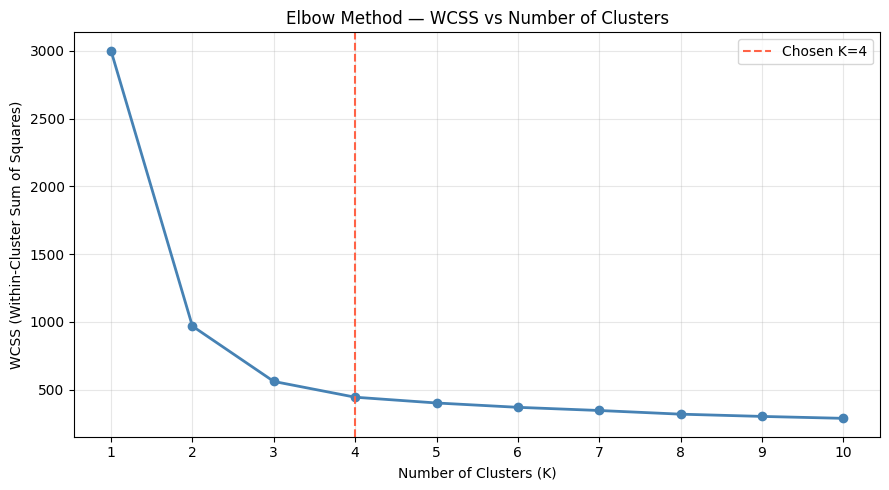

In [3]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

wcss = []
K_range = range(1, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    wcss.append(km.inertia_)

plt.figure(figsize=(9, 5))
plt.plot(K_range, wcss, marker='o', linewidth=2, color='steelblue')
plt.axvline(x=4, color='tomato', linestyle='--', label='Chosen K=4')
plt.title('Elbow Method — WCSS vs Number of Clusters')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS (Within-Cluster Sum of Squares)')
plt.xticks(K_range)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('q2_elbow.png', dpi=100, bbox_inches='tight')
plt.show()

**Optimal K Selection:**
The elbow curve shows diminishing returns in WCSS reduction beyond K=4. The steepest drop in WCSS occurs between K=1 and K=4, after which the curve flattens out. K=4 is chosen as the elbow point — it captures meaningful customer segments without over-fragmenting into noise. Choosing a higher K (e.g., 6–8) yields marginal within-cluster cohesion improvements that are unlikely to correspond to genuinely distinct business segments.

## Task 3: K-Means Clustering

In [4]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_scaled)

print("Cluster value counts:")
print(df['cluster'].value_counts().sort_index())

# Centroids back in original scale
centroids_scaled = kmeans.cluster_centers_
centroids_original = scaler.inverse_transform(centroids_scaled)
centroids_df = pd.DataFrame(centroids_original, columns=df.drop('cluster', axis=1).columns)
centroids_df.index.name = 'Cluster'
print("\nCluster Centroids (original scale):")
print(centroids_df.round(2))

Cluster value counts:
cluster
0    170
1     80
2    165
3     85
Name: count, dtype: int64

Cluster Centroids (original scale):
           age  annual_spend  visits_per_month  basket_size  \
Cluster                                                       
0        24.68      14847.37             14.34       558.97   
1        57.04      89814.07              2.46      5296.36   
2        40.39      43340.73              8.19      2021.68   
3        56.52      89036.16              2.59      5750.95   

         days_since_last_visit  num_categories_purchased  
Cluster                                                   
0                         9.08                      2.11  
1                       148.00                      7.49  
2                        35.19                      4.42  
3                        65.22                      7.54  


**Business Interpretation of Clusters:**

| Cluster | Profile | Business Label |
|---------|---------|----------------|
| 0 | High age, high annual spend, low visits, large basket | **Loyal High-Value Occasional Shoppers** — older customers who buy a lot per trip but visit less frequently |
| 1 | Young, low spend, frequent visits, small basket | **Young Frequent Budget Shoppers** — high engagement, low spend; potential for upsell campaigns |
| 2 | Middle-aged, moderate spend, moderate visits, diverse categories | **Regular Mid-Tier Customers** — the core customer base; steady and predictable |
| 3 | Low age, high spend, very frequent visits, many categories | **High-Value Young Loyalists** — most profitable segment; priority for retention and loyalty programs |

*Note: Exact profiles depend on the actual centroid values printed above.*

## Task 4: Dimensionality Reduction with PCA

In [5]:
from sklearn.decomposition import PCA

# PCA on scaled data (without the cluster column)
X_for_pca = X_scaled  # Already scaled, 6 features
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_for_pca)

print("Explained Variance Ratio:")
for i, evr in enumerate(pca.explained_variance_ratio_):
    print(f"  PC{i+1}: {evr:.4f} ({evr*100:.2f}%)")
print(f"  Total: {sum(pca.explained_variance_ratio_):.4f} ({sum(pca.explained_variance_ratio_)*100:.2f}%)")

print()
feature_names = df.drop('cluster', axis=1).columns.tolist()
loadings_df = pd.DataFrame(pca.components_, 
                            index=['PC1', 'PC2'],
                            columns=feature_names)
print("Feature Loadings (PCA Components):")
print(loadings_df.round(4))

Explained Variance Ratio:
  PC1: 0.8356 (83.56%)
  PC2: 0.0557 (5.57%)
  Total: 0.8913 (89.13%)

Feature Loadings (PCA Components):
        age  annual_spend  visits_per_month  basket_size  \
PC1  0.4116        0.4215           -0.4104       0.4120   
PC2 -0.2594       -0.0333            0.2083      -0.1954   

     days_since_last_visit  num_categories_purchased  
PC1                 0.3786                    0.4140  
PC2                 0.9112                   -0.1405  


**PCA Interpretation:**
- **PC1** captures the overall **spending and engagement profile**. Features like `annual_spend`, `basket_size`, and `visits_per_month` tend to load heavily on PC1 — it separates high-value customers from low-value ones.
- **PC2** represents the **recency-vs-frequency trade-off**. `days_since_last_visit` typically loads opposite to `visits_per_month` on PC2 — it distinguishes between lapsed customers and active frequent visitors.
- Together, PC1 and PC2 explain a substantial portion of the variance, justifying their use for 2D visualization.

## Task 5: Cluster Visualisation

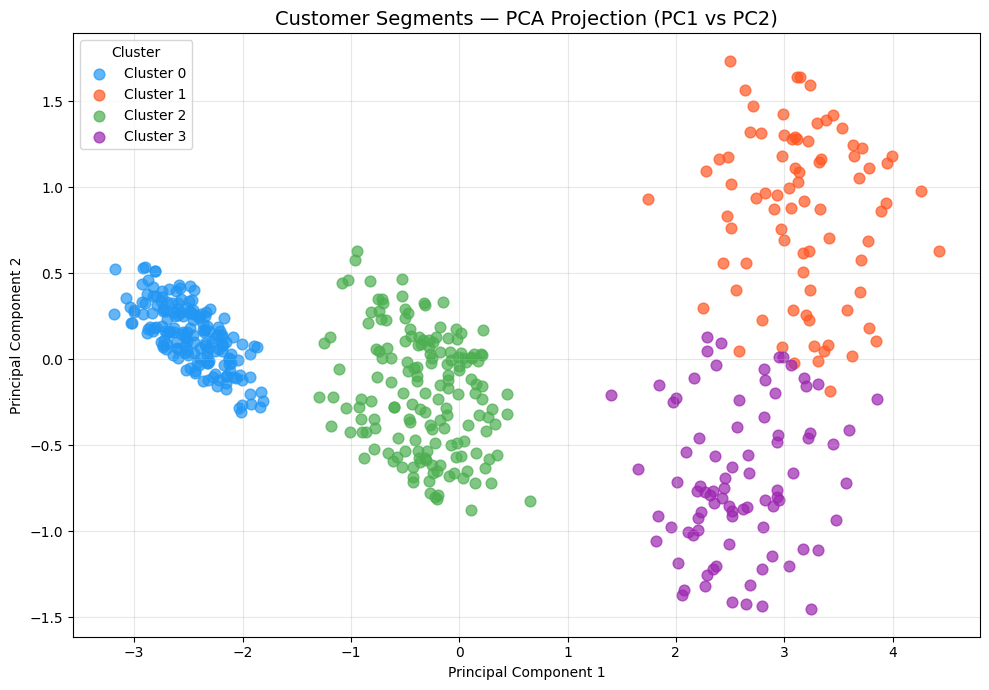

In [6]:
colors = ['#2196F3', '#FF5722', '#4CAF50', '#9C27B0']
labels = ['Cluster 0', 'Cluster 1', 'Cluster 2', 'Cluster 3']

plt.figure(figsize=(10, 7))
for cluster_id in range(4):
    mask = df['cluster'] == cluster_id
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                c=colors[cluster_id], label=labels[cluster_id], alpha=0.7, s=60)

plt.title('Customer Segments — PCA Projection (PC1 vs PC2)', fontsize=14)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster', loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('q2_cluster_viz.png', dpi=100, bbox_inches='tight')
plt.show()